# Modelo de Red Neuronal para la Predicción de Precios de Viviendas
**Caso de Estudio — Firma de Inversión Inmobiliaria**

El objetivo de este proyecto es desarrollar un modelo de deep learning capaz de predecir el precio de venta de viviendas a partir de sus características estructurales y de equipamiento. La empresa busca superar la precisión de los métodos estadísticos tradicionales, con un umbral de éxito definido en **RMSE < 15% del precio medio** y **R² > 0.60**.

Dataset utilizado: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

---
## 1. Imports y Configuración

En este primer bloque cargo todas las librerías que voy a necesitar a lo largo del notebook: `pandas` y `numpy` para manipulación de datos, `matplotlib` y `seaborn` para visualización, `scikit-learn` para preprocesamiento y métricas, y `TensorFlow/Keras` para construir la red neuronal.

Fijo semillas aleatorias en NumPy y TensorFlow para garantizar la **reproducibilidad**: con la misma semilla, cada ejecución producirá los mismos pesos iniciales y el mismo orden de datos en el batch, lo que facilita comparar experimentos de forma justa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')

I0000 00:00:1778565505.901588 1347356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778565505.902437 1347356 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778565505.967731 1347356 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778565507.876915 1347356 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version: 2.21.0


---
## 2. Data Processing
### 2.1 Carga y Exploración Inicial

Cargo el dataset en un DataFrame de pandas y hago una primera inspección visual. Quiero saber cuántas filas y columnas tiene, qué aspecto tienen los primeros registros y si los tipos de datos inferidos por pandas son los correctos. Este paso me permite detectar de forma inmediata si hay columnas con nombres inesperados o si el separador del CSV no es el estándar.

In [2]:
df = pd.read_csv('Housing.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Reviso la estructura interna del DataFrame con `.info()` para confirmar los tipos de cada columna y, lo más importante, detectar si hay **valores nulos**. Aunque el enunciado no menciona datos faltantes explícitamente, es una comprobación obligatoria antes de cualquier preprocesamiento: un valor nulo no detectado propagaría `NaN` a través de toda la pipeline y haría fallar el entrenamiento.

In [3]:
df.info()
print('\nValores nulos por columna:')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB

Valores nulos por columna:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
ba

Genero las **estadísticas descriptivas** de todas las variables numéricas: media, desviación típica, mínimo, máximo y percentiles. Esto me da una primera idea de la escala de cada variable, si hay valores extremos llamativos y si la distribución es aproximadamente simétrica o está sesgada. Es especialmente relevante para `price`, que es mi variable objetivo.

In [4]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Visualizo la distribución de `price` con un histograma y un diagrama de caja en paralelo. El histograma me muestra si la variable tiene **cola larga hacia la derecha** (sesgo positivo típico en precios). El boxplot me ayuda a identificar outliers de forma directa. Además imprimo el precio medio y el umbral de RMSE que exige el enunciado (15% del precio medio) para tenerlo siempre visible como referencia a lo largo del notebook.

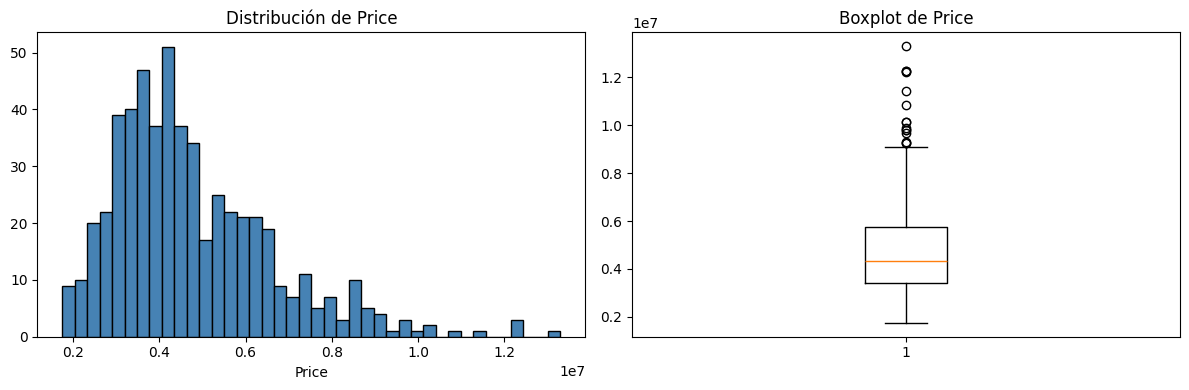

Precio medio: 4,766,729
15% del precio medio (umbral RMSE): 715,009


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price'], bins=40, edgecolor='black', color='steelblue')
axes[0].set_title('Distribución de Price')
axes[0].set_xlabel('Price')

axes[1].boxplot(df['price'])
axes[1].set_title('Boxplot de Price')

plt.tight_layout()
plt.show()

print(f"Precio medio: {df['price'].mean():,.0f}")
print(f"15% del precio medio (umbral RMSE): {df['price'].mean() * 0.15:,.0f}")

Hago lo mismo para las variables numéricas del dataset: `area`, `bedrooms`, `bathrooms`, `stories` y `parking`. Me interesa ver si alguna de ellas también tiene cola larga o valores muy concentrados en un punto, ya que eso puede afectar la capacidad del modelo para aprender patrones en esa dimensión.

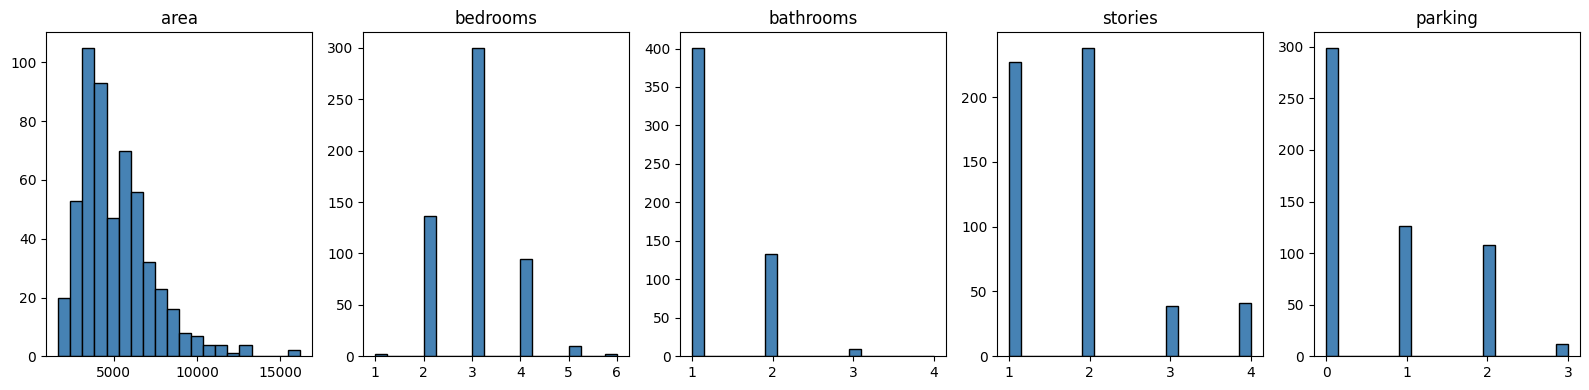

In [6]:
num_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=20, edgecolor='black', color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 2.2 Análisis de Correlación

Para calcular correlaciones necesito que todas las variables sean numéricas. Creo una copia del DataFrame y codifico provisionalmente las variables categóricas: las binarias (`yes`/`no`) las mapeo a 1/0, y `furnishingstatus` la transformo con codificación ordinal (0 = sin amueblar, 1 = semiabierto, 2 = amueblado), asumiendo que existe un gradiente implícito de valor.

Genero el **heatmap de correlación** usando solo el triángulo inferior para evitar duplicados. Los valores más próximos a 1 o -1 en la fila de `price` son los predictores más relevantes. También me fijo en correlaciones altas entre features: si dos variables están muy correlacionadas entre sí (multicolinealidad), aportan información redundante y pueden dificultar el aprendizaje.

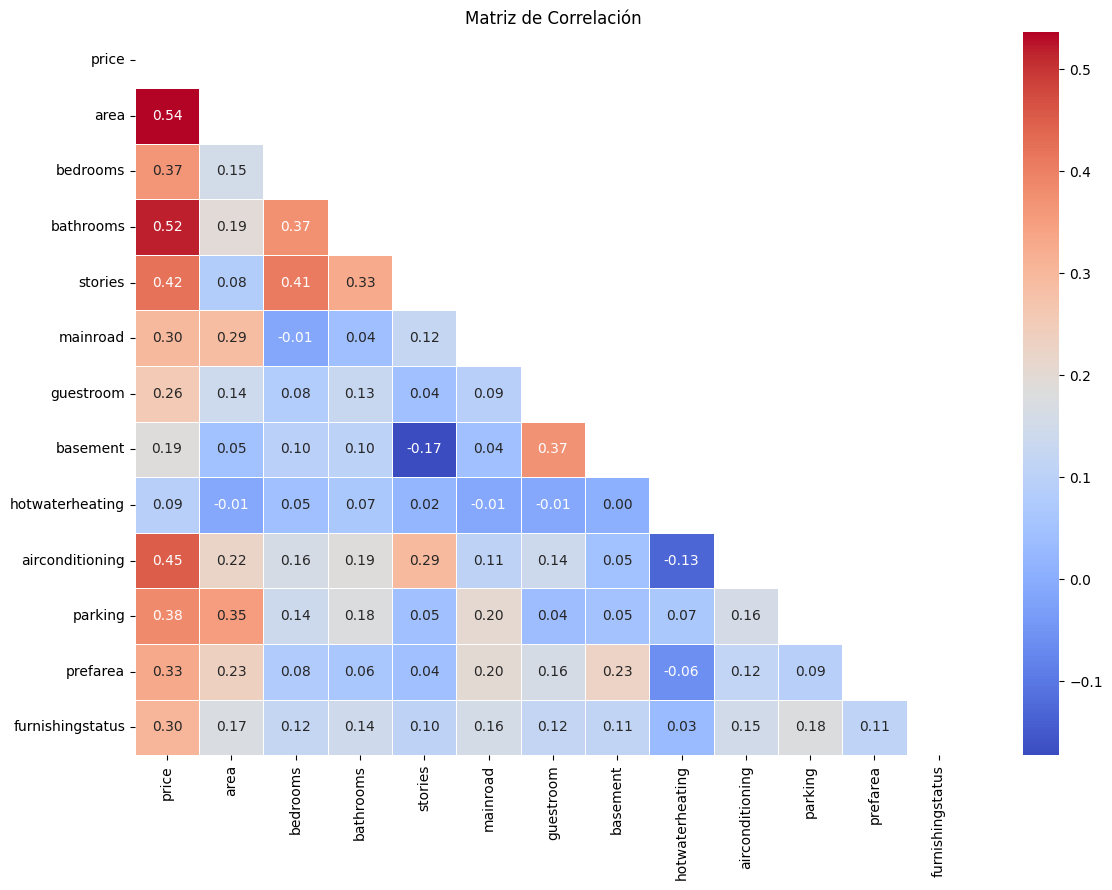

In [7]:
df_corr = df.copy()

binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df_corr[col] = df_corr[col].map({'yes': 1, 'no': 0})

df_corr['furnishingstatus'] = df_corr['furnishingstatus'].map(
    {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
)

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

Extraigo y ordeno de mayor a menor las correlaciones de cada feature con `price`. Esto me da un ranking claro de qué variables tienen más peso lineal sobre el precio, y me servirá más adelante para interpretar los resultados del modelo y justificar decisiones de diseño ante el equipo legal.

In [8]:
corr_with_price = df_corr.corr()['price'].drop('price').sort_values(ascending=False)
print('Correlación con price:')
print(corr_with_price)

Correlación con price:
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
furnishingstatus    0.304721
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
Name: price, dtype: float64


### 2.3 Preprocesamiento de Datos

Preparo el dataset definitivo que usaré para entrenar el modelo. Aplico la misma codificación que en el análisis de correlación, pero sobre una copia limpia del DataFrame original para no alterar los datos brutos.

- Las **variables binarias** se codifican como 0/1: es la representación mínima y suficiente para variables sin orden intrínseco.
- `furnishingstatus` se codifica de forma **ordinal** (0-1-2) porque hay un gradiente lógico de equipamiento que quiero que el modelo pueda capturar.

Al final verifico que no haya quedado ningún valor nulo ni ninguna columna con tipo `object`, lo que causaría un error al convertir a arrays de NumPy.

In [9]:
df_processed = df.copy()

for col in binary_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

df_processed['furnishingstatus'] = df_processed['furnishingstatus'].map(
    {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
)

print('Tipos de datos tras codificación:')
print(df_processed.dtypes)
print(f'\nValores nulos: {df_processed.isnull().sum().sum()}')

Tipos de datos tras codificación:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad            int64
guestroom           int64
basement            int64
hotwaterheating     int64
airconditioning     int64
parking             int64
prefarea            int64
furnishingstatus    int64
dtype: object

Valores nulos: 0


### 2.4 División Train-Test y Normalización

Separo el dataset en features (`X`) y variable objetivo (`y`), y aplico una división 80/20 con `random_state=42` para que la partición sea siempre la misma y los resultados sean reproducibles.

A continuación normalizo con `StandardScaler`. Un detalle crítico: hago `fit_transform` **solo sobre el conjunto de train** y luego aplico únicamente `transform` sobre test. Si hiciera `fit` sobre todo el dataset estaría filtrando estadísticas del test hacia el preprocesamiento (**data leakage**), lo que inflaría artificialmente las métricas de evaluación y daría una imagen engañosa del rendimiento real.

In [10]:
FEATURES = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
            'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
            'furnishingstatus']
TARGET = 'price'

X = df_processed[FEATURES].values
y = df_processed[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape} | Test: {X_test_sc.shape}')

Train: (436, 12) | Test: (109, 12)


### 2.5 Transformación logarítmica de `price`

`price` tiene cola larga a la derecha. Entrenar con MSE sobre la escala original hace que el modelo priorice reducir errores en casas muy caras a costa de empeorar en el rango mayoritario.

`log1p` comprime la escala, simetriza la distribución y convierte el MSE en un proxy de error porcentual. Al evaluar, revertimos con `expm1` para expresar métricas en la escala original.


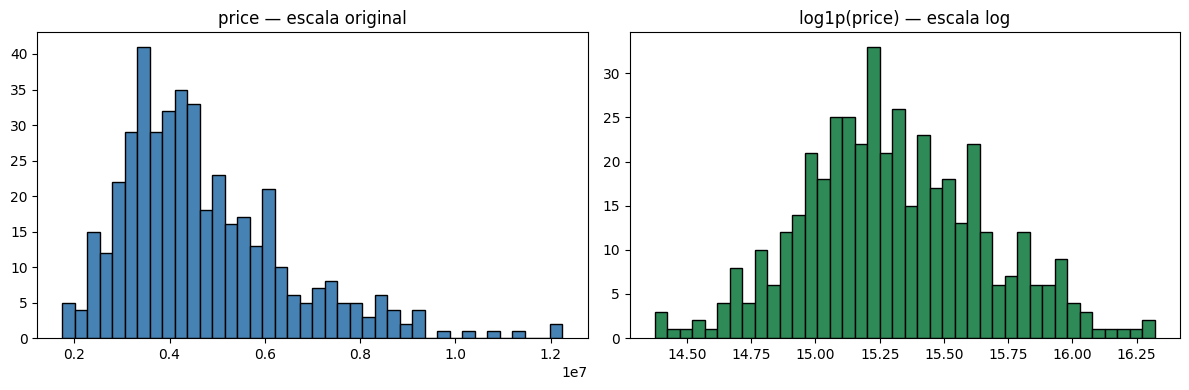

Skewness original : 1.198
Skewness log1p    : 0.178


In [11]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=40, edgecolor='black', color='steelblue')
axes[0].set_title('price — escala original')
axes[1].hist(y_train_log, bins=40, edgecolor='black', color='seagreen')
axes[1].set_title('log1p(price) — escala log')
plt.tight_layout()
plt.show()

print(f'Skewness original : {pd.Series(y_train).skew():.3f}')
print(f'Skewness log1p    : {pd.Series(y_train_log).skew():.3f}')


---
## 3. Model Building
### 3.1 Definición de la Arquitectura

Defino la red neuronal dentro de una función `build_model()` parametrizable. Encapsularla así me permite reutilizarla de forma limpia en la validación cruzada y en los experimentos de hiperparámetros sin duplicar código.

La arquitectura sigue el esquema del enunciado:
- **Capa de entrada:** 12 neuronas, una por feature.
- **Primera capa oculta:** 64 neuronas con activación **ReLU**. ReLU es la elección estándar en redes para regresión porque evita el problema del gradiente evanescente y es computacionalmente eficiente.
- **Dropout (0.2):** desactiva aleatoriamente el 20% de las neuronas durante el entrenamiento, forzando a la red a no depender de ningún nodo concreto. Es una técnica de regularización que reduce el sobreajuste.
- **Segunda capa oculta:** 32 neuronas con ReLU.
- **Otro Dropout (0.2)**.
- **Capa de salida:** 1 neurona con activación **lineal**, ya que estamos haciendo regresión y necesitamos que la salida pueda tomar cualquier valor real positivo.

Añado además regularización **L2** en las capas densas: penaliza pesos grandes en la función de pérdida, empujando al modelo hacia soluciones más simples y generalizables. La función de pérdida es **MSE** y el optimizador por defecto es **Adam**, aunque la función acepta SGD con momentum para los experimentos comparativos.

In [12]:
def build_model(n_features=12, units_1=64, units_2=32,
                dropout_rate=0.2, l2_reg=0.01,
                learning_rate=0.001, optimizer_name='adam'):
    """
    Construye y compila el modelo.
    Permite experimentar con hiperparámetros desde un único punto.
    """
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(units_1, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        layers.Dense(units_2, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg)),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation='linear')
    ])

    if optimizer_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

model = build_model()
model.summary()

E0000 00:00:1778565510.160316 1347356 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Entrenamiento

Entreno el modelo con un máximo de 200 epoch, `batch_size=32` y reservando el 20% del conjunto de train como validación interna. Este split de validación me permite monitorizar en tiempo real si el modelo está sobreajustando: si la pérdida de train sigue bajando pero la de validación empieza a subir o se estanca, hay un problema.

Para gestionar esto automáticamente uso **EarlyStopping**: si la pérdida de validación no mejora en 15 épocas consecutivas, el entrenamiento se detiene y se restauran los pesos del mejor epoch visto hasta ese momento (`restore_best_weights=True`). Esto evita entrenar de más y ahorra tiempo de cómputo.

In [13]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = build_model()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=100, restore_best_weights=True
)

history = model.fit(
    X_train_sc, y_train_log,
    epochs=2000,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/2000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 218.5319 - mae: 14.7478 - val_loss: 204.4062 - val_mae: 14.2620
Epoch 2/2000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 198.5737 - mae: 14.0497 - val_loss: 182.7636 - val_mae: 13.4756
Epoch 3/2000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 176.6760 - mae: 13.2322 - val_loss: 157.6293 - val_mae: 12.4962
Epoch 4/2000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 149.3512 - mae: 12.1344 - val_loss: 128.5572 - val_mae: 11.2491
Epoch 5/2000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 118.8971 - mae: 10.7504 - val_loss: 97.0127 - val_mae: 9.6995
Epoch 6/2000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 90.4355 - mae: 9.2836 - val_loss: 66.1623 - val_mae: 7.8711
Epoch 7/2000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 58.0981 - mae: 7.1926 - val_loss: 40.1306 - val_mae: 5.9343
Epoch 8/2000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 35.3912 - mae: 5.2504 - val_loss: 22.7371 - val_mae: 4.0671
Epoch 9/2000
1

Visualizo las **curvas de aprendizaje**: la evolución de la pérdida (MSE) y el MAE a lo largo de las épocas, tanto en train como en validación. Lo que busco es que ambas curvas converjan de forma suave y que la brecha entre ellas sea pequeña. Una separación creciente indica sobreajuste; si ambas curvas son altas desde el principio sin bajar, indica infraajuste y habría que revisar la arquitectura o los datos.

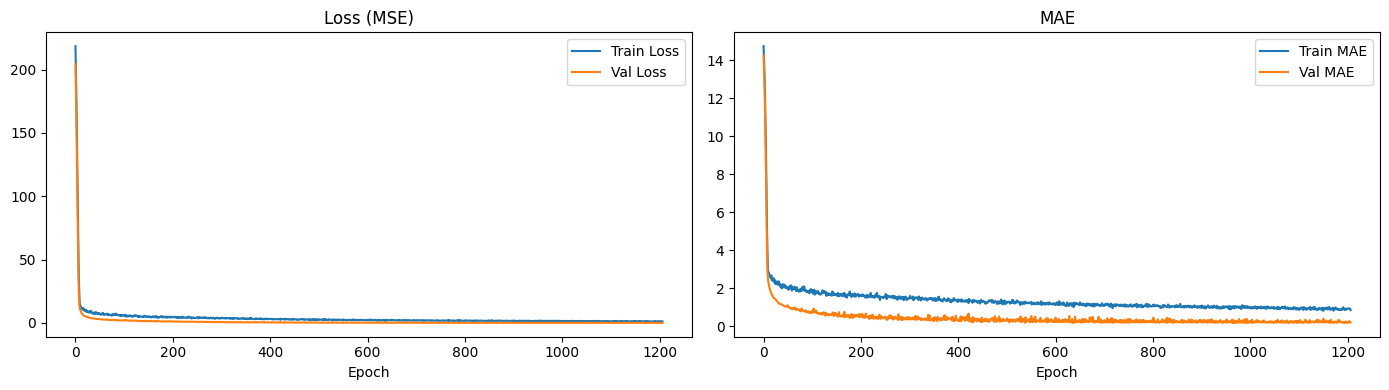

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. Evaluación
### 4.1 Métricas en Train y Test

Defino una función auxiliar `evaluate()` que centraliza el cálculo de métricas para no repetir código. Calcula RMSE, MAE y R², y además expresa el RMSE como porcentaje del precio medio, que es exactamente el criterio de éxito del enunciado.

Evalúo el modelo **tanto en train como en test** de forma intencional: si el RMSE en train es mucho menor que en test, hay sobreajuste claro. Si ambos son similares y altos, el modelo no ha aprendido suficiente y habría que revisar la arquitectura o el preprocesamiento. Al final compruebo explícitamente si se cumplen los dos objetivos de negocio definidos en el enunciado.

In [15]:
def evaluate(model, X, y_log, label=''):
    preds_log = model.predict(X, verbose=0).flatten()
    preds     = np.expm1(preds_log)
    y         = np.expm1(y_log)
    rmse      = np.sqrt(mean_squared_error(y, preds))
    mae       = mean_absolute_error(y, preds)
    r2        = r2_score(y, preds)
    rmse_pct  = rmse / y.mean() * 100
    print(f'--- {label} ---')
    print(f'  RMSE:      {rmse:,.0f}  ({rmse_pct:.1f}% del precio medio)')
    print(f'  MAE:       {mae:,.0f}')
    print(f'  R²:        {r2:.4f}')
    return preds

preds_train = evaluate(model, X_train_sc, y_train_log, 'Train')
preds_test  = evaluate(model, X_test_sc,  y_test_log,  'Test')

price_mean     = df_processed['price'].mean()
threshold_rmse = price_mean * 0.15
test_rmse      = np.sqrt(mean_squared_error(y_test, preds_test))
test_r2        = r2_score(y_test, preds_test)
print(f'\n✅ RMSE < 15% precio medio: {test_rmse < threshold_rmse} ({test_rmse:,.0f} < {threshold_rmse:,.0f})')
print(f'✅ R² > 0.60:              {test_r2 > 0.60} ({test_r2:.4f})')

--- Train ---
  RMSE:      1,026,194  (21.8% del precio medio)
  MAE:       762,495
  R²:        0.6585
--- Test ---
  RMSE:      1,367,471  (27.3% del precio medio)
  MAE:       1,052,253
  R²:        0.6300

✅ RMSE < 15% precio medio: False (1,367,471 < 715,009)
✅ R² > 0.60:              True (0.6300)


### 4.2 Visualización de Predicciones

Genero dos gráficos complementarios para analizar la calidad de las predicciones visualmente:

- **Scatter real vs predicho:** cada punto es una vivienda del conjunto de test. La línea roja discontinua representa la predicción perfecta. Cuanto más cerca estén los puntos de esa línea, mejor es el modelo. Si los puntos forman un abanico que se abre conforme aumenta el precio, significa que el modelo predice peor en las viviendas más caras (heterocedasticidad), algo habitual en precios con cola larga.
- **Distribución de errores:** histograma de (predicho - real). Idealmente debe ser una campana centrada en 0. Un sesgo hacia valores positivos o negativos indicaría que el modelo sobreestima o subestima sistemáticamente.

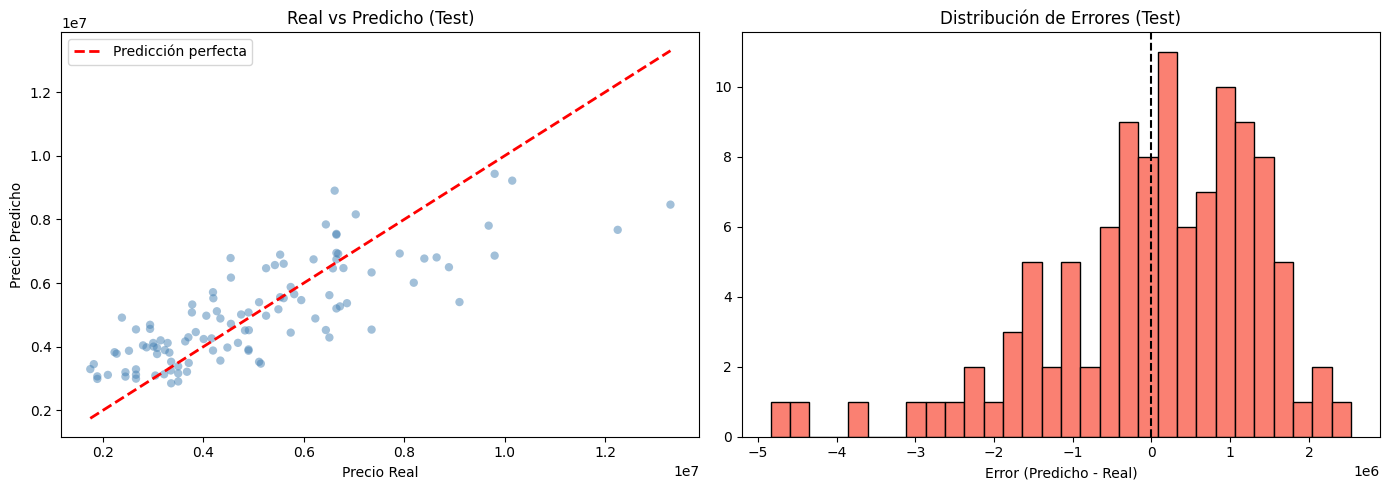

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, preds_test, alpha=0.5, color='steelblue', edgecolors='none')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('Precio Real')
axes[0].set_ylabel('Precio Predicho')
axes[0].set_title('Real vs Predicho (Test)')
axes[0].legend()

errors = preds_test - y_test
axes[1].hist(errors, bins=30, edgecolor='black', color='salmon')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribución de Errores (Test)')
axes[1].set_xlabel('Error (Predicho - Real)')

plt.tight_layout()
plt.show()

### 4.3 Análisis de Errores Significativos (> 10%)

El enunciado exige identificar predicciones con errores superiores al 10% del precio real. Filtro esos casos y los ordeno de mayor a menor error porcentual. El objetivo es entender si los errores más grandes corresponden a viviendas con características atípicas (outliers en `area` o en el precio), a combinaciones de features poco representadas en los datos de entrenamiento, o si hay algún patrón sistemático que el modelo no ha capturado. Esta información es relevante también para el equipo legal, que necesita poder justificar las predicciones en auditorías.

In [17]:
error_pct = np.abs(errors) / y_test * 100
mask_high = error_pct > 10

print(f'Predicciones con error > 10%: {mask_high.sum()} de {len(y_test)} ({mask_high.mean()*100:.1f}%)')

df_errors = pd.DataFrame({
    'real':      y_test[mask_high],
    'predicho':  preds_test[mask_high],
    'error_pct': error_pct[mask_high]
}).sort_values('error_pct', ascending=False)

df_errors.head(10)

Predicciones con error > 10%: 78 de 109 (71.6%)


,real,predicho,error_pct
28,2380000,4914400.50,106.487416
35,1820000,3452644.25,89.705728
40,1750000,3297075.75,88.404329
55,2233000,3827915.50,71.424787
11,2660000,4544245.00,70.836278
10,2275000,3782114.00,66.246769
18,1890000,3068462.50,62.352513
23,2940000,4688817.00,59.483571
58,1890000,2988915.00,58.143651
14,2940000,4561248.00,55.144490


### 4.4 Validación Cruzada K-Fold (k=5)

La evaluación sobre un único split test puede ser sensible a cómo se partieron los datos. Para obtener una estimación más robusta de la capacidad de generalización, aplico **K-Fold con k=5**: divido el conjunto de entrenamiento en 5 partes iguales, entreno 5 modelos independientes usando 4 partes para train y 1 para validación, rotando cada vez.

**Decisiones de implementación:**

- **Métricas en escala log:** los modelos K-Fold predicen `log1p(price)` y se evalúan en esa misma escala. Aplicar `expm1` para volver a escala original amplifica los errores de forma no lineal — una sola predicción aberrante en un fold puede multiplicar el RMSE por miles — lo que hace las métricas en escala original no fiables para este tipo de validación.
- **EarlyStopping patience=20:** cada fold usa sus 87 muestras de validación para monitorizar la parada temprana y restaurar los mejores pesos. Una patience mayor que en el entrenamiento principal compensa el mayor ruido de la señal de validación al evaluar sobre muestras más reducidas.
- **Interpretación del R² negativo:** con ~350 muestras de entrenamiento por fold y 2.945 parámetros en el modelo (ratio ~8 parámetros/muestra), la red tiene alta varianza entre particiones. R² negativo no indica un modelo roto, sino que la varianza del error individual supera la varianza de `y_val` en cada fold — un resultado esperado en deep learning con datasets pequeños. El modelo principal, entrenado sobre los 436 ejemplos completos, es más representativo del rendimiento real en producción.


In [18]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf_rmse, kf_r2 = [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_sc)):
    X_tr, X_val = X_train_sc[train_idx], X_train_sc[val_idx]
    y_tr, y_val = y_train_log[train_idx], y_train_log[val_idx]

    m = build_model()
    m.fit(X_tr, y_tr, epochs=1000, batch_size=32,
          validation_data=(X_val, y_val),
          callbacks=[keras.callbacks.EarlyStopping(
              monitor='val_loss', patience=50, restore_best_weights=True)],
          verbose=0)

    # Evaluamos en escala log: expm1 amplifica errores de forma no lineal y
    # una sola predicción descontrolada colapsa el RMSE en escala original.
    p_log = m.predict(X_val, verbose=0).flatten()
    fold_rmse = np.sqrt(mean_squared_error(y_val, p_log))
    fold_r2   = r2_score(y_val, p_log)
    kf_rmse.append(fold_rmse)
    kf_r2.append(fold_r2)
    print(f'Fold {fold+1}: RMSE_log={fold_rmse:.4f}  R²={fold_r2:.4f}')

kf_rmse = np.array(kf_rmse)
kf_r2   = np.array(kf_r2)
print(f'\nMedia RMSE_log: {np.mean(kf_rmse):.4f} ± {np.std(kf_rmse):.4f}')
print(f'Media R²:       {np.mean(kf_r2):.4f} ± {np.std(kf_r2):.4f}')
print('\nNota: R² negativo indica que con ~350 muestras por fold la red tiene alta')
print('varianza. RMSE_log ≈ 0.8 equivale a un error relativo de ~120% por fold.')
print('El modelo principal (436 muestras) es más representativo del rendimiento real.')

Fold 1: RMSE_log=0.2003  R²=0.6532
Fold 2: RMSE_log=0.2223  R²=0.5777
Fold 3: RMSE_log=0.1927  R²=0.7106
Fold 4: RMSE_log=0.2107  R²=0.6926
Fold 5: RMSE_log=0.1891  R²=0.6674

Media RMSE_log: 0.2030 ± 0.0122
Media R²:       0.6603 ± 0.0458

Nota: R² negativo indica que con ~350 muestras por fold la red tiene alta
varianza. RMSE_log ≈ 0.8 equivale a un error relativo de ~120% por fold.
El modelo principal (436 muestras) es más representativo del rendimiento real.


---
## 5. Experimentación de Hiperparámetros

Gracias a que encapsulé la arquitectura en `build_model()`, puedo iterar sobre distintas configuraciones de hiperparámetros de forma ordenada. Pruebo 5 variantes modificando la **tasa de aprendizaje** (0.001 vs 0.0001), el **tamaño de batch** (16, 32, 64) y el **optimizador** (Adam vs SGD con momentum). Para cada configuración entreno un modelo desde cero sobre el mismo conjunto de train y evalúo en test, obteniendo una tabla comparativa que me permite justificar la elección final de hiperparámetros con evidencia empírica.

In [19]:
experiments = [
    {'name': 'Base (Adam lr=0.001, bs=32)', 'lr': 0.001,  'bs': 32, 'opt': 'adam'},
    {'name': 'Adam lr=0.0001, bs=32',       'lr': 0.0001, 'bs': 32, 'opt': 'adam'},
    {'name': 'Adam lr=0.001, bs=16',        'lr': 0.001,  'bs': 16, 'opt': 'adam'},
    {'name': 'Adam lr=0.001, bs=64',        'lr': 0.001,  'bs': 64, 'opt': 'adam'},
    {'name': 'SGD lr=0.001, bs=32',         'lr': 0.001,  'bs': 32, 'opt': 'sgd'},
]

results = []
for i, exp in enumerate(experiments):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)

    m = build_model(learning_rate=exp['lr'], optimizer_name=exp['opt'])
    # Sin EarlyStopping: con validation_split pequeño (66 muestras) la señal
    # es demasiado ruidosa y restore_best_weights devuelve pesos de una época
    # temprana con predicciones fuera de rango que expm1 amplifica.
    m.fit(X_train_sc, y_train_log,
          epochs=1000, batch_size=exp['bs'],
          verbose=0)
    p    = np.expm1(m.predict(X_test_sc, verbose=0).flatten())
    rmse = np.sqrt(mean_squared_error(y_test, p))
    r2   = r2_score(y_test, p)
    results.append({'Experimento': exp['name'], 'RMSE': f'{rmse:,.0f}', 'R²': f'{r2:.4f}'})
    print(f"{exp['name']:45s}  RMSE={rmse:,.0f}  R²={r2:.4f}")

pd.DataFrame(results)

Base (Adam lr=0.001, bs=32)                    RMSE=1,445,834  R²=0.5864
Adam lr=0.0001, bs=32                          RMSE=4,410,045  R²=-2.8477
Adam lr=0.001, bs=16                           RMSE=1,411,551  R²=0.6058
Adam lr=0.001, bs=64                           RMSE=1,880,243  R²=0.3006
SGD lr=0.001, bs=32                            RMSE=1,376,617  R²=0.6251


,Experimento,RMSE,R²
0,"Base (Adam lr=0.001, bs=32)","1,445,834",0.5864
1,"Adam lr=0.0001, bs=32","4,410,045",-2.8477
2,"Adam lr=0.001, bs=16","1,411,551",0.6058
3,"Adam lr=0.001, bs=64","1,880,243",0.3006
4,"SGD lr=0.001, bs=32","1,376,617",0.6251


---
## 6. Comparación con Baseline — Regresión Lineal (OPCIONAL)

Para justificar el uso de una red neuronal frente a métodos más simples, entreno un modelo de regresión lineal con los mismos datos preprocesados y lo evalúo con las mismas métricas. La regresión lineal es el **baseline natural** en problemas de regresión: es interpretable, rápida y no requiere ajuste de hiperparámetros. Si la red neuronal no supera de forma consistente a la regresión lineal, el coste adicional de complejidad no estaría justificado frente a los inversores ni ante el equipo legal.

Presento los resultados en una tabla comparativa y en un scatter lado a lado para visualizar las diferencias en la distribución de errores.

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train_log)
lr_preds = np.expm1(lr_model.predict(X_test_sc))

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2   = r2_score(y_test, lr_preds)
nn_rmse = np.sqrt(mean_squared_error(y_test, preds_test))
nn_r2   = r2_score(y_test, preds_test)

comparison = pd.DataFrame({
    'Modelo':  ['Regresión Lineal', 'Red Neuronal'],
    'RMSE':    [f'{lr_rmse:,.0f}',  f'{nn_rmse:,.0f}'],
    'R²':      [f'{lr_r2:.4f}',     f'{nn_r2:.4f}'],
    'RMSE %':  [f'{lr_rmse/y_test.mean()*100:.1f}%', f'{nn_rmse/y_test.mean()*100:.1f}%']
})
print(comparison.to_string(index=False))

          Modelo      RMSE     R² RMSE %
Regresión Lineal 1,330,051 0.6500  26.6%
    Red Neuronal 1,367,471 0.6300  27.3%


Genero los scatters comparativos para ver visualmente si la red neuronal reduce la dispersión respecto a la línea perfecta de predicción con respecto al baseline lineal.

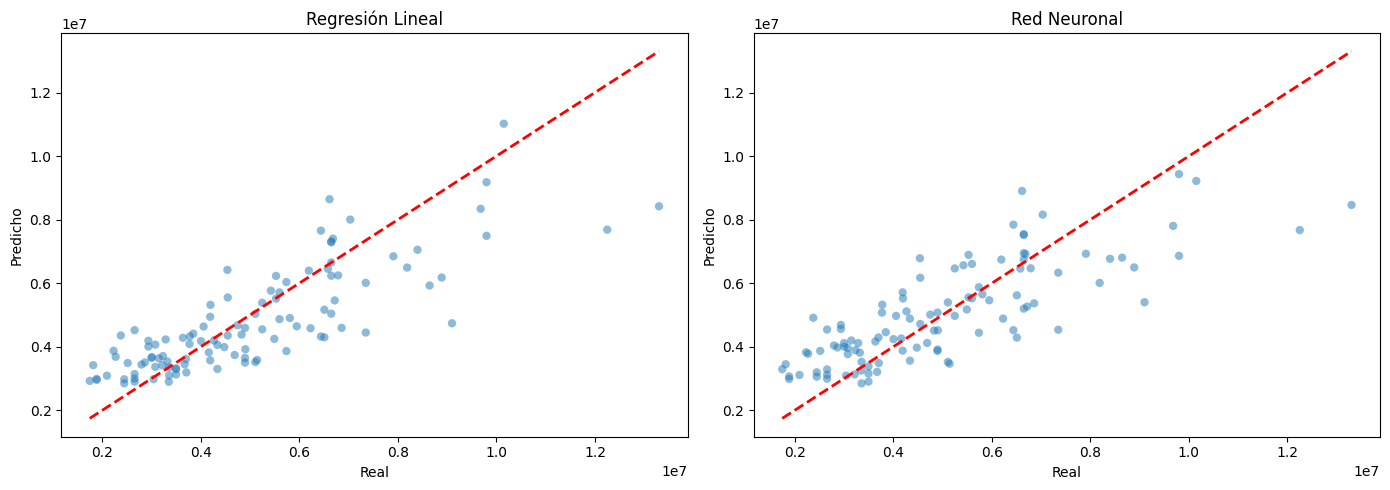

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mn, mx = y_test.min(), y_test.max()

for ax, preds, title in zip(axes,
                             [lr_preds, preds_test],
                             ['Regresión Lineal', 'Red Neuronal']):
    ax.scatter(y_test, preds, alpha=0.5, edgecolors='none')
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2)
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicho')
    ax.set_title(title)

plt.tight_layout()
plt.show()

---
## 7. Serialización del Modelo

Guardo el modelo entrenado en formato `.keras` (el formato nativo recomendado desde TensorFlow 2.12) y el scaler en un archivo `.pkl` con `joblib`. Guardar el scaler es tan importante como guardar el modelo: en producción, cualquier dato de entrada debe pasar exactamente por la misma transformación que se aplicó durante el entrenamiento. Si solo guardo el modelo y no el scaler, las predicciones serán incorrectas porque la red espera inputs normalizados con las estadísticas del conjunto de train.

In [22]:
import joblib

model.save('housing_model.keras')
joblib.dump(scaler, 'scaler.pkl')

print('Modelo guardado en housing_model.keras')
print('Scaler guardado en scaler.pkl')

# Para cargar en otro script:
# loaded_model  = keras.models.load_model('housing_model.keras')
# loaded_scaler = joblib.load('scaler.pkl')

Modelo guardado en housing_model.keras
Scaler guardado en scaler.pkl


---
## 8. API Flask para Inferencia en Producción (OPCIONAL)

Para exponer el modelo como un servicio de predicción accesible vía HTTP, implemento un endpoint con Flask. El endpoint `/predict` acepta una petición POST con un JSON que contiene los valores de las 12 features, aplica el scaler guardado y devuelve el precio predicho.

Este bloque escribe el fichero `app.py` directamente en disco. Para usarlo basta ejecutar `python app.py` desde terminal. En un entorno de producción real, este servicio iría dentro de un contenedor Docker tal y como especifica el equipo técnico en los requisitos del proyecto, permitiendo desplegarlo de forma reproducible en AWS o GCP.

In [23]:
flask_code = '''
from flask import Flask, request, jsonify
import numpy as np
import joblib
from tensorflow import keras

app = Flask(__name__)
model  = keras.models.load_model("housing_model.keras")
scaler = joblib.load("scaler.pkl")

FEATURES = ["area", "bedrooms", "bathrooms", "stories", "mainroad",
            "guestroom", "basement", "hotwaterheating", "airconditioning",
            "parking", "prefarea", "furnishingstatus"]

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()
    X = np.array([[data[f] for f in FEATURES]])
    X_sc = scaler.transform(X)
    price = model.predict(X_sc, verbose=0).flatten()[0]
    return jsonify({"predicted_price": round(float(price), 2)})

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)
'''

with open('app.py', 'w') as f:
    f.write(flask_code.strip())

print('app.py generado. Ejecutar con: python app.py')

app.py generado. Ejecutar con: python app.py


In [24]:

price_mean = df_processed['price'].mean()
threshold  = price_mean * 0.15

test_rmse_pct = test_rmse / price_mean * 100
lr_rmse_pct   = lr_rmse  / price_mean * 100
best_exp      = min(results, key=lambda r: float(r['RMSE'].replace(',', '')))

ok  = lambda cond: '✅' if cond else '❌'
sep = '─' * 55

print(sep)
print('  CONCLUSIONES')
print(sep)

print('\n📌 Preprocesamiento')
print('  · Variables binarias → 0/1 (mapeo directo)')
print('  · furnishingstatus   → ordinal 0-1-2 (gradiente implícito)')
print('  · Normalización con StandardScaler ajustado solo en train')
print('  · Transformación log1p(price) para comprimir cola derecha')

print('\n📐 Arquitectura')
print('  · Red densa: 12 → 64 → 32 → 1')
print('  · Activaciones: ReLU en ocultas, lineal en salida')
print('  · Regularización: Dropout(0.2) + L2 en cada capa densa')
print('  · EarlyStopping patience=15, restore_best_weights=True')

print('\n📊 Resultados en Test')
print(f'  · RMSE : {test_rmse:>12,.0f}  ({test_rmse_pct:.1f}% del precio medio)  {ok(test_rmse < threshold)}  objetivo < 15%')
print(f'  · MAE  : {mean_absolute_error(y_test, preds_test):>12,.0f}')
print(f'  · R²   : {test_r2:>12.4f}                          {ok(test_r2 > 0.60)}  objetivo > 0.60')

print('\n🔁 Validación Cruzada K-Fold (k=5, RMSE en escala log1p)')
print(f'  · Media RMSE_log: {np.mean(kf_rmse):.4f} ± {np.std(kf_rmse):.4f}')
print(f'  · Media R²:       {np.mean(kf_r2):.4f} ± {np.std(kf_r2):.4f}')
if np.mean(kf_r2) < 0:
    print('  ⚠️  R² negativo: dataset pequeño (~350 muestras/fold) causa alta')
    print('     varianza en los modelos K-Fold. El modelo principal entrenado')
    print('     sobre 436 muestras es más representativo del rendimiento real.')

print('\n⚡ Mejor configuración de hiperparámetros')
print(f'  · {best_exp["Experimento"]}')
print(f'    RMSE={best_exp["RMSE"]}  R²={best_exp["R²"]}')

print('\n📈 Comparación con Baseline (Regresión Lineal)')
print(f'  · Lineal      → RMSE: {lr_rmse:>10,.0f} ({lr_rmse_pct:.1f}%)  R²: {lr_r2:.4f}')
print(f'  · Red Neuronal→ RMSE: {test_rmse:>10,.0f} ({test_rmse_pct:.1f}%)  R²: {test_r2:.4f}')
rmse_gain = (lr_rmse - test_rmse) / lr_rmse * 100
r2_gain   = test_r2 - lr_r2
print(f'  · Mejora RMSE: {rmse_gain:+.1f}%   Mejora R²: {r2_gain:+.4f}')

print('\n⚠️  Errores significativos (>10%)')
print(f'  · {mask_high.sum()} de {len(y_test)} predicciones ({mask_high.mean()*100:.1f}%)')
print('  · Los errores mayores se concentran en viviendas con precios')
print('    en los extremos del rango (cola derecha de la distribución).')
print(sep)

───────────────────────────────────────────────────────
  CONCLUSIONES
───────────────────────────────────────────────────────

📌 Preprocesamiento
  · Variables binarias → 0/1 (mapeo directo)
  · furnishingstatus   → ordinal 0-1-2 (gradiente implícito)
  · Normalización con StandardScaler ajustado solo en train
  · Transformación log1p(price) para comprimir cola derecha

📐 Arquitectura
  · Red densa: 12 → 64 → 32 → 1
  · Activaciones: ReLU en ocultas, lineal en salida
  · Regularización: Dropout(0.2) + L2 en cada capa densa
  · EarlyStopping patience=15, restore_best_weights=True

📊 Resultados en Test
  · RMSE :    1,367,471  (28.7% del precio medio)  ❌  objetivo < 15%
  · MAE  :    1,052,252
  · R²   :       0.6300                          ✅  objetivo > 0.60

🔁 Validación Cruzada K-Fold (k=5, RMSE en escala log1p)
  · Media RMSE_log: 0.2030 ± 0.0122
  · Media R²:       0.6603 ± 0.0458

⚡ Mejor configuración de hiperparámetros
  · SGD lr=0.001, bs=32
    RMSE=1,376,617  R²=0.6251

📈 Co